# Exploratory Data Analysis 

## Job roles to explore: 

In [1]:
# importing libraries
import ast 
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt 
import seaborn as sns

# loading the dataset
dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\amrit\anaconda3\envs\py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Filtering for the Data Analyst roles in India 

In [2]:
df_DA_India = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

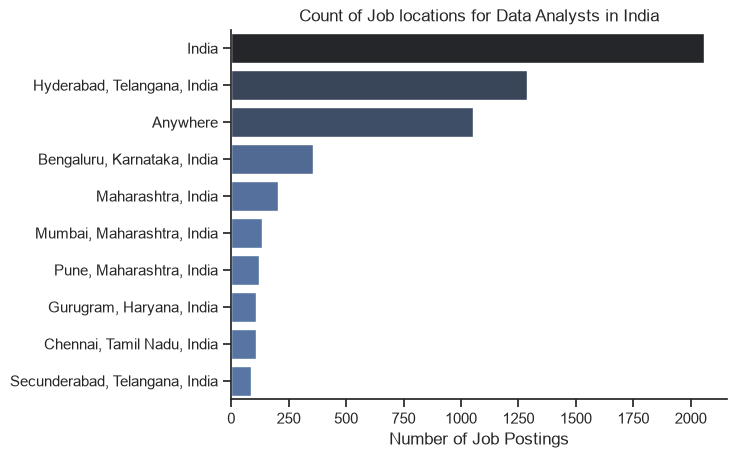

In [25]:
df_plot = df_DA_India['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Job locations for Data Analysts in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()

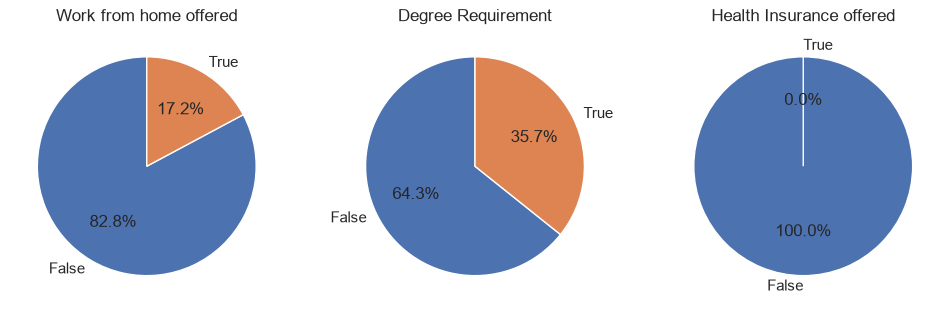

In [20]:
dict_column = {
  'job_work_from_home' : 'Work from home offered',
  'job_no_degree_mention' : 'Degree Requirement',
  'job_health_insurance' : 'Health Insurance offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
  counts = (df_DA_India[column].value_counts().reindex([False, True], fill_value=0))
  ax[i].pie(counts,labels=['False', 'True'],autopct='%1.1f%%', startangle=90)
  ax[i].set_title(title)

plt.show()

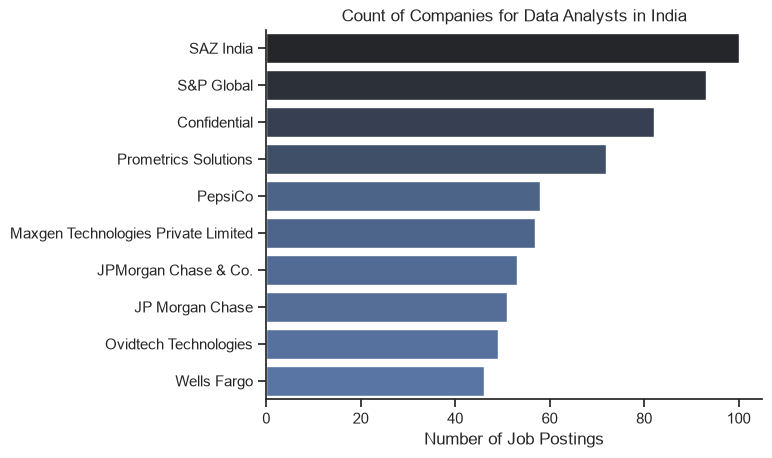

In [26]:
df_plot = df_DA_India['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style="ticks")
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Companies for Data Analysts in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()